# 🤖 Pipeline 3: Supervised Machine Learning & Evaluation Suite
**Project:** Build For Bharat 2.0 — CareerGPS Talent Intelligence  
**Track:** SAS & Data Science Track  

### Overview & Methodology
This notebook trains, validates, and interprets supervised machine learning models predicting career outcomes:
1. **JDS Model**: Predicts Junior DS high salary hike probability based on measured technical competencies.
2. **SDS Model**: Predicts Senior DS high project success probability based on Big Five (OCEAN) psychometric traits.

### Methodological Rigor:
- **Strict Leakage Prevention**: Standard scalers are fitted exclusively within each cross-validation split via scikit-learn `Pipeline`.
- **Repeated Stratified K-Fold CV**: 5 Folds $\times$ 5 Repeats = **25 independent train-test splits** per model to ensure unbiased generalization on small-N samples.
- **Model Diversity**: Dummy Baseline (most frequent), Regularized Logistic Regression, Decision Tree, and Random Forest Classifier.
- **Metrics Tracked**: Accuracy, Balanced Accuracy, Precision, Recall, F1-Score, and ROC-AUC (mean $\pm$ std).


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)

cleaned_dir = os.path.abspath(os.path.join("..", "data", "cleaned"))
reports_dir = os.path.abspath(os.path.join("..", "reports"))
os.makedirs(reports_dir, exist_ok=True)

# Load data
df_jds = pd.read_csv(os.path.join(cleaned_dir, "clean_jds_skill_traits.csv"))
df_sds = pd.read_csv(os.path.join(cleaned_dir, "clean_sds_personality_traits.csv"))

jds_features = ['big_data_skills', 'maths-stats_skills', 'coding_skills', 'ai_and_ml_skills', 'dashboard_and_storytelling_skills']
sds_features = ['neuroticism', 'extraversion', 'openness_to_experience', 'agreeableness', 'conscientiousness']

X_jds, y_jds = df_jds[jds_features], df_jds['salary_hike_high_or_low']
X_sds, y_sds = df_sds[sds_features], df_sds['success_classification_high_low']

print(f"JDS dataset: N={len(X_jds)}, Class 1={y_jds.sum()} ({y_jds.mean()*100:.1f}%), Class 0={len(y_jds)-y_jds.sum()}")
print(f"SDS dataset: N={len(X_sds)}, Class 1={y_sds.sum()} ({y_sds.mean()*100:.1f}%), Class 0={len(y_sds)-y_sds.sum()}")


JDS dataset: N=139, Class 1=73 (52.5%), Class 0=66
SDS dataset: N=161, Class 1=85 (52.8%), Class 0=76


## 1. Cross-Validation & Evaluation Architecture
Define model candidates and execute 5-Fold $\times$ 5-Repeat Stratified Cross Validation (25 evaluations per model).


In [2]:
def get_models(random_state=42):
    return {
        'Dummy (most_frequent)': DummyClassifier(strategy='most_frequent'),
        'Logistic Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=random_state))
        ]),
        'Decision Tree': DecisionTreeClassifier(
            max_depth=3, min_samples_leaf=5, min_samples_split=10, random_state=random_state
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=100, max_depth=4, min_samples_leaf=3, min_samples_split=6,
            max_features='sqrt', random_state=random_state
        )
    }

def run_repeated_cv(X, y, random_state=42):
    rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=random_state)
    models = get_models(random_state)
    
    results = {}
    for name, model in models.items():
        accs, b_accs, precs, recs, f1s, aucs = [], [], [], [], [], []
        
        for train_idx, test_idx in rskf.split(X, y):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            accs.append(accuracy_score(y_test, y_pred))
            b_accs.append(balanced_accuracy_score(y_test, y_pred))
            precs.append(precision_score(y_test, y_pred, zero_division=0))
            recs.append(recall_score(y_test, y_pred, zero_division=0))
            f1s.append(f1_score(y_test, y_pred, zero_division=0))
            
            try:
                y_prob = model.predict_proba(X_test)[:, 1]
                aucs.append(roc_auc_score(y_test, y_prob))
            except Exception:
                aucs.append(0.5)
                
        results[name] = {
            'Accuracy': f"{np.mean(accs):.3f} ± {np.std(accs):.3f}",
            'Balanced Acc': f"{np.mean(b_accs):.3f} ± {np.std(b_accs):.3f}",
            'Precision': f"{np.mean(precs):.3f} ± {np.std(precs):.3f}",
            'Recall': f"{np.mean(recs):.3f} ± {np.std(recs):.3f}",
            'F1-Score': f"{np.mean(f1s):.3f} ± {np.std(f1s):.3f}",
            'ROC-AUC': f"{np.mean(aucs):.3f} ± {np.std(aucs):.3f}",
            'raw_acc': np.mean(accs),
            'raw_f1': np.mean(f1s),
            'raw_auc': np.mean(aucs)
        }
    return pd.DataFrame(results).T

print("Cross-Validation framework initialized.")


Cross-Validation framework initialized.


## 2. Model Performance on Junior Data Scientist (JDS) Dataset
Evaluating baseline vs machine learning algorithms on predicting salary hikes.


In [3]:
jds_cv_results = run_repeated_cv(X_jds, y_jds)
print("=== JDS 5x5 REPEATED STRATIFIED CV EVALUATION ===")
display(jds_cv_results[['Accuracy', 'Balanced Acc', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']])


=== JDS 5x5 REPEATED STRATIFIED CV EVALUATION ===


,Accuracy,Balanced Acc,Precision,Recall,F1-Score,ROC-AUC
Dummy (most_frequent),0.525 ± 0.014,0.500 ± 0.000,0.525 ± 0.014,1.000 ± 0.000,0.689 ± 0.012,0.500 ± 0.000
Logistic Regression,0.853 ± 0.069,0.850 ± 0.071,0.842 ± 0.081,0.895 ± 0.075,0.865 ± 0.064,0.904 ± 0.058
Decision Tree,0.784 ± 0.063,0.782 ± 0.062,0.779 ± 0.067,0.834 ± 0.112,0.800 ± 0.062,0.820 ± 0.075
Random Forest,0.837 ± 0.071,0.837 ± 0.070,0.845 ± 0.070,0.849 ± 0.104,0.844 ± 0.070,0.883 ± 0.065


## 3. Model Performance on Senior Data Scientist (SDS) Dataset
Evaluating baseline vs machine learning algorithms on predicting customer success.


In [4]:
sds_cv_results = run_repeated_cv(X_sds, y_sds)
print("=== SDS 5x5 REPEATED STRATIFIED CV EVALUATION ===")
display(sds_cv_results[['Accuracy', 'Balanced Acc', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']])


=== SDS 5x5 REPEATED STRATIFIED CV EVALUATION ===


,Accuracy,Balanced Acc,Precision,Recall,F1-Score,ROC-AUC
Dummy (most_frequent),0.528 ± 0.006,0.500 ± 0.000,0.528 ± 0.006,1.000 ± 0.000,0.691 ± 0.006,0.500 ± 0.000
Logistic Regression,0.922 ± 0.049,0.920 ± 0.050,0.907 ± 0.067,0.955 ± 0.051,0.929 ± 0.044,0.964 ± 0.037
Decision Tree,0.906 ± 0.057,0.904 ± 0.056,0.901 ± 0.066,0.932 ± 0.103,0.911 ± 0.059,0.940 ± 0.041
Random Forest,0.944 ± 0.041,0.943 ± 0.040,0.944 ± 0.050,0.955 ± 0.077,0.946 ± 0.043,0.996 ± 0.007


## 4. Out-of-Fold Confusion Matrices & ROC Curves
Visualizing discrimination thresholds, False Positive vs False Negative trade-offs, and AUC scores.


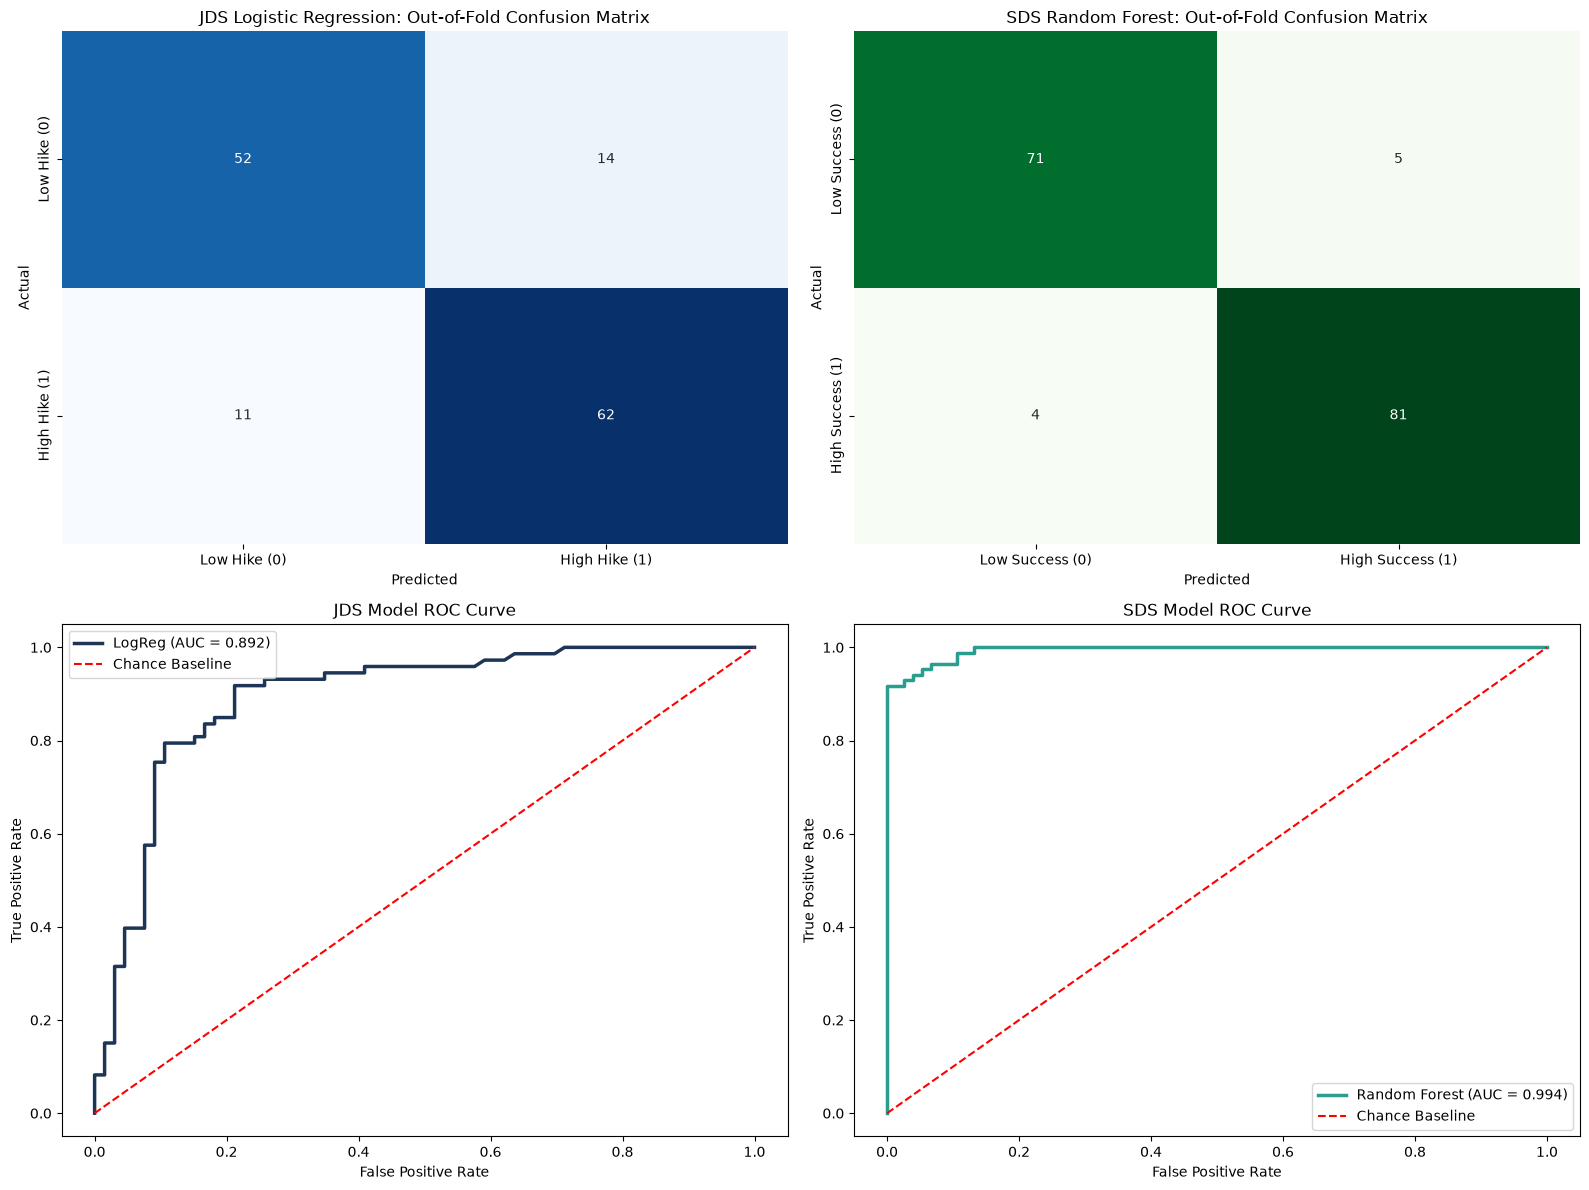

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Compute out-of-fold predictions
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# JDS Best Model (Logistic Regression)
jds_model = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(random_state=42))])
y_oof_pred_jds = np.zeros(len(y_jds))
y_oof_prob_jds = np.zeros(len(y_jds))

for tr, te in skf.split(X_jds, y_jds):
    jds_model.fit(X_jds.iloc[tr], y_jds.iloc[tr])
    y_oof_pred_jds[te] = jds_model.predict(X_jds.iloc[te])
    y_oof_prob_jds[te] = jds_model.predict_proba(X_jds.iloc[te])[:, 1]

# SDS Best Model (Random Forest)
sds_model = RandomForestClassifier(n_estimators=100, max_depth=4, min_samples_leaf=3, random_state=42)
y_oof_pred_sds = np.zeros(len(y_sds))
y_oof_prob_sds = np.zeros(len(y_sds))

for tr, te in skf.split(X_sds, y_sds):
    sds_model.fit(X_sds.iloc[tr], y_sds.iloc[tr])
    y_oof_pred_sds[te] = sds_model.predict(X_sds.iloc[te])
    y_oof_prob_sds[te] = sds_model.predict_proba(X_sds.iloc[te])[:, 1]

# Plot Confusion Matrices
cm_jds = confusion_matrix(y_jds, y_oof_pred_jds)
sns.heatmap(cm_jds, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar=False,
            xticklabels=['Low Hike (0)', 'High Hike (1)'], yticklabels=['Low Hike (0)', 'High Hike (1)'])
axes[0, 0].set_title("JDS Logistic Regression: Out-of-Fold Confusion Matrix")
axes[0, 0].set_xlabel("Predicted")
axes[0, 0].set_ylabel("Actual")

cm_sds = confusion_matrix(y_sds, y_oof_pred_sds)
sns.heatmap(cm_sds, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1], cbar=False,
            xticklabels=['Low Success (0)', 'High Success (1)'], yticklabels=['Low Success (0)', 'High Success (1)'])
axes[0, 1].set_title("SDS Random Forest: Out-of-Fold Confusion Matrix")
axes[0, 1].set_xlabel("Predicted")
axes[0, 1].set_ylabel("Actual")

# ROC Curves
fpr_jds, tpr_jds, _ = roc_curve(y_jds, y_oof_prob_jds)
auc_jds = roc_auc_score(y_jds, y_oof_prob_jds)
axes[1, 0].plot(fpr_jds, tpr_jds, color='#1d3557', lw=2.5, label=f"LogReg (AUC = {auc_jds:.3f})")
axes[1, 0].plot([0, 1], [0, 1], 'r--', lw=1.5, label="Chance Baseline")
axes[1, 0].set_title("JDS Model ROC Curve")
axes[1, 0].set_xlabel("False Positive Rate")
axes[1, 0].set_ylabel("True Positive Rate")
axes[1, 0].legend(frameon=True)

fpr_sds, tpr_sds, _ = roc_curve(y_sds, y_oof_prob_sds)
auc_sds = roc_auc_score(y_sds, y_oof_prob_sds)
axes[1, 1].plot(fpr_sds, tpr_sds, color='#2a9d8f', lw=2.5, label=f"Random Forest (AUC = {auc_sds:.3f})")
axes[1, 1].plot([0, 1], [0, 1], 'r--', lw=1.5, label="Chance Baseline")
axes[1, 1].set_title("SDS Model ROC Curve")
axes[1, 1].set_xlabel("False Positive Rate")
axes[1, 1].set_ylabel("True Positive Rate")
axes[1, 1].legend(frameon=True)

plt.tight_layout()
plt.show()


## 5. Feature Importance & Model Interpretability
- **JDS Logistic Regression**: Odds Ratios ($e^{\beta}$) indicating how each standard deviation increase in a skill increases the likelihood of a high salary hike.
- **SDS Random Forest**: Gini impurity feature importances illustrating the strongest psychometric determinants of senior leadership success.


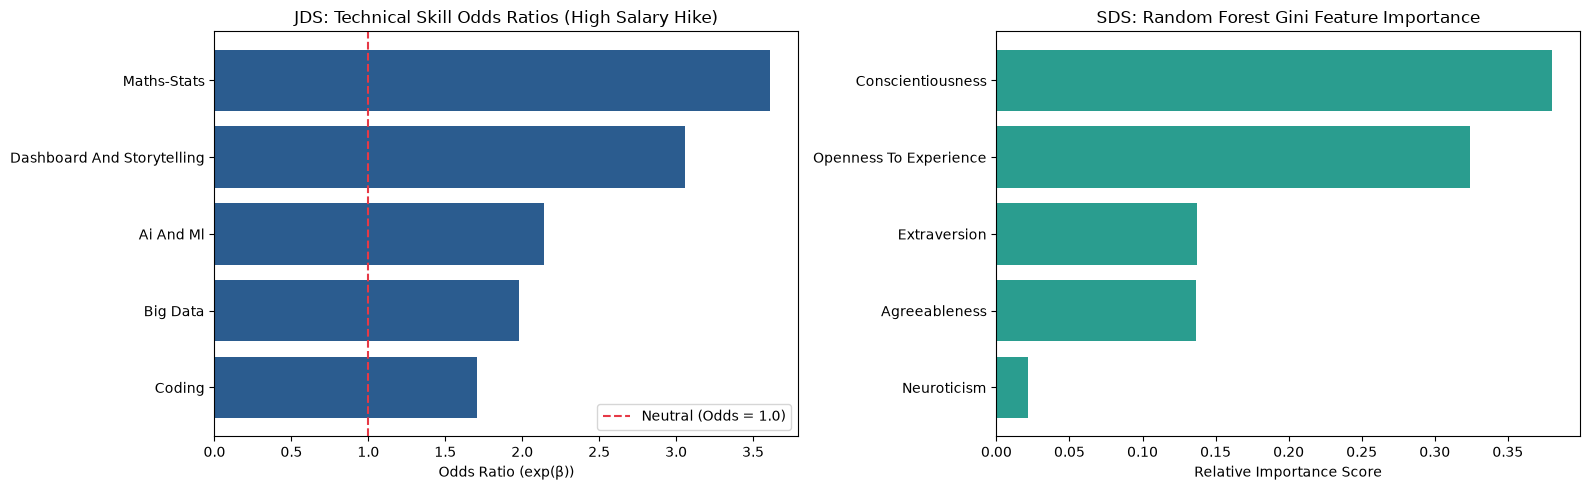

Feature analysis complete.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Fit full models for interpretability
jds_model.fit(X_jds, y_jds)
coefs = jds_model.named_steps['clf'].coef_[0]
odds_ratios = np.exp(coefs)

df_jds_imp = pd.DataFrame({'Skill': [s.replace('_skills', '').replace('_', ' ').title() for s in jds_features], 'Odds_Ratio': odds_ratios})
df_jds_imp = df_jds_imp.sort_values(by='Odds_Ratio', ascending=True)

axes[0].barh(df_jds_imp['Skill'], df_jds_imp['Odds_Ratio'], color='#2b5c8f')
axes[0].axvline(1.0, color='#e63946', linestyle='--', label='Neutral (Odds = 1.0)')
axes[0].set_title("JDS: Technical Skill Odds Ratios (High Salary Hike)")
axes[0].set_xlabel("Odds Ratio (exp(β))")
axes[0].legend(frameon=True)

sds_model.fit(X_sds, y_sds)
importances = sds_model.feature_importances_

df_sds_imp = pd.DataFrame({'Trait': [t.replace('_', ' ').title() for t in sds_features], 'Importance': importances})
df_sds_imp = df_sds_imp.sort_values(by='Importance', ascending=True)

axes[1].barh(df_sds_imp['Trait'], df_sds_imp['Importance'], color='#2a9d8f')
axes[1].set_title("SDS: Random Forest Gini Feature Importance")
axes[1].set_xlabel("Relative Importance Score")

plt.tight_layout()
plt.show()

print("Feature analysis complete.")
